In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd

from unit_converter import UnitConverter
from fault import FaultSimulator
from topologia import FeederTopology
from locator import FaultLocator

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [ ]:
DSS_FILE = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe/data/34Bus/Run_IEEE34Mod1.dss')

In [13]:
simulador = FaultSimulator(str(DSS_FILE))

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001, 10.0]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()



Iniciando a varredura linear de curtos-circuitos...


Simulando Faltas:   0%|          | 0/1920 [00:00<?, ?it/s]

Aplicando Filtro MI: 100%|██████████| 1488/1488 [00:00<00:00, 3684.93it/s]


In [11]:
localizador.df

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,circuito_9_d,circuito_9_line,linha_estimada,dist_estimada,erro_percentual
0,14894.615725,-140.507583,-7499.666997,-13044.186057,-7499.389193,13100.728892,37724.473689,-38336.462003,-20.001642,-29.313789,...,l1,235.915202,l1,235.915202,l1,235.915202,l1,l1,235.915194,-1.035676e-08
1,15094.512970,-55.551757,-7565.719247,-12829.479045,-7547.502016,13017.222161,36.810785,-2.146939,-52045.741836,-12771.856391,...,l1,235.915191,l1,235.915192,l1,235.915191,l1,l1,235.915185,-2.626232e-08
2,15046.726915,27.473243,-7595.583146,-13044.696869,-7326.841437,12967.935263,38.797542,-4.293698,-16.948709,-28.280374,...,l1,235.915192,l1,235.915193,l1,235.915193,l1,l1,235.915186,-2.388840e-08
3,14996.551278,-345.415014,-7449.427745,-12727.130477,-7547.158702,13072.549189,64080.789271,-6234.650424,-64063.881208,6180.096292,...,l1,235.915184,l1,235.915184,l1,235.915184,l1,l1,235.915185,-2.659105e-08
4,15094.713245,-0.297030,-7766.760489,-12812.157575,-7327.959900,12812.446275,56.547217,-10.283278,-38868.162293,-47055.029125,...,l1,235.915190,l1,235.915190,l1,235.915190,l1,l1,235.915190,-1.805577e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1483,15094.518621,-0.339631,-7547.570211,-13072.308800,-7546.965803,13072.636425,70.615226,-43.993060,-27.682175,-35.417997,...,l26,54699.408000,l28,58981.848000,l31,55930.800000,l32,l32,55930.800000,5.573442e-01
1484,15094.669383,-0.404359,-7547.610704,-13072.136954,-7547.165636,13072.552215,75.717374,-22.034719,-58.159581,-54.795085,...,l26,54699.408000,l28,58981.848000,l31,55930.800000,l32,l32,55930.800000,5.573442e-01
1485,15094.707108,-0.276473,-7547.668594,-13072.177218,-7547.013138,13072.516861,47.723003,-9.796239,-53.423662,-54.016976,...,l26,54699.408000,l28,58981.848000,l31,55930.800000,l32,l32,55930.800000,5.573442e-01
1486,15094.597014,-0.369889,-7547.568991,-13072.295569,-7547.019337,13072.587127,78.292077,-27.084666,-25.195675,-33.518603,...,l26,54699.408000,l28,58981.848000,l31,55930.800000,l32,l32,55930.800000,5.573442e-01


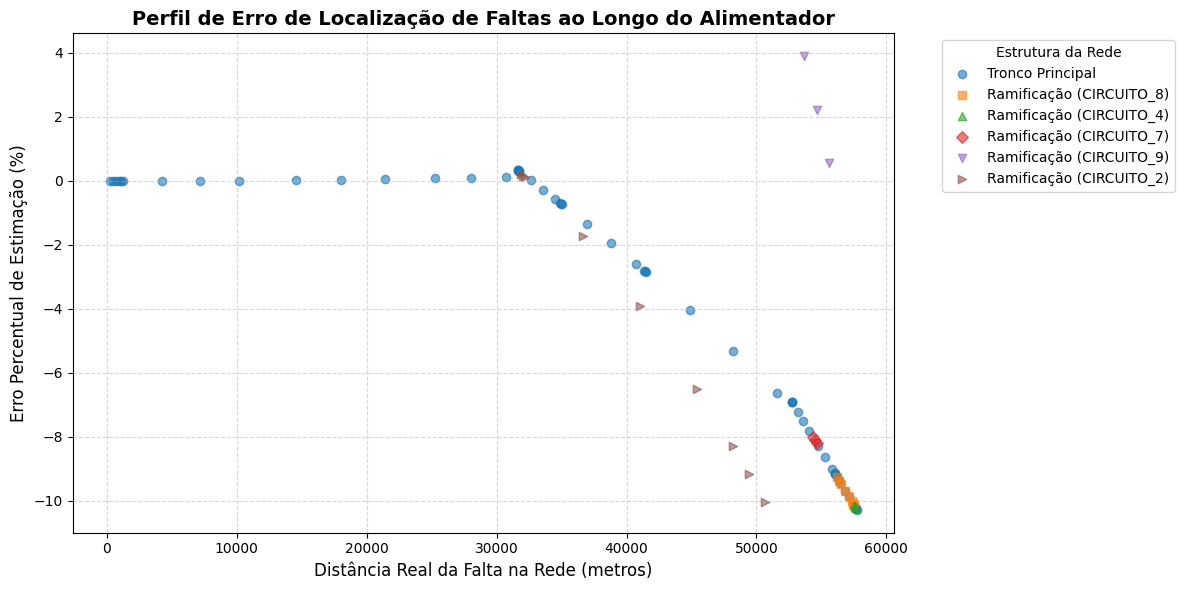

In [12]:

import matplotlib.pyplot as plt

"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(12, 6))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'at') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()